In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# def detect_columns(df):
    
#     cols = {col.lower(): col for col in df.columns}
#     detected = {}

#     for key in cols:
#         if "heart" in key or "hr" in key:
#             detected["hr"] = cols[key]

#     for key in cols:
#         if "oxygen" in key or "spo2" in key:
#             detected["spo2"] = cols[key]

#     for key in cols:
#         if "resp" in key:
#             detected["resp"] = cols[key]

#     for key in cols:
#         if "pressure" in key or "bp" in key:
#             detected["bp"] = cols[key]

#     return detected

# def detect_columns(df):
    
#     cols = {col.lower(): col for col in df.columns}
#     detected = {}

#     for key in cols:
#         if "heart rate" in key:
#             detected["hr"] = cols[key]

#     for key in cols:
#         if "spo2" in key or "oxygen" in key:
#             detected["spo2"] = cols[key]

#     for key in cols:
#         if "respiration" in key:
#             detected["resp"] = cols[key]

#     for key in cols:
#         if "systolic" in key:
#             detected["bp_sys"] = cols[key]

#     for key in cols:
#         if "diastolic" in key:
#             detected["bp_dia"] = cols[key]

#     return detected

def detect_columns(df):
    
    detected = {}
    
    # Normalize column names
    cols = {col.lower().replace("_", " ").strip(): col for col in df.columns}
    
    # -------------------------
    # Heart Rate
    # -------------------------
    hr_keywords = ["heart rate", "hr", "pulse"]
    
    for key in cols:
        if any(k in key for k in hr_keywords):
            detected["hr"] = cols[key]
    
    # -------------------------
    # SpO2 / Oxygen
    # -------------------------
    spo2_keywords = ["spo2", "oxygen", "o2"]
    
    for key in cols:
        if any(k in key for k in spo2_keywords):
            detected["spo2"] = cols[key]
    
    # -------------------------
    # Respiration
    # -------------------------
    resp_keywords = ["respiration", "breath", "resp"]
    
    for key in cols:
        if any(k in key for k in resp_keywords):
            detected["resp"] = cols[key]
    
    # -------------------------
    # Blood Pressure Detection
    # -------------------------
    
    for key in cols:
        if "systolic" in key:
            detected["bp_sys"] = cols[key]
    
    for key in cols:
        if "diastolic" in key:
            detected["bp_dia"] = cols[key]
    
    # 🔥 NEW: full BP column like "120/80"
    for key in cols:
        if "blood pressure" in key or key.strip() == "bp":
            detected["bp_full"] = cols[key]
    
    return detected

In [3]:
def split_bp_safe(df, bp_col):
    
    systolic = []
    diastolic = []
    
    for val in df[bp_col]:
        try:
            s, d = str(val).split('/')
            systolic.append(float(s))
            diastolic.append(float(d))
        except:
            systolic.append(np.nan)
            diastolic.append(np.nan)
    
    df["Systolic"] = systolic
    df["Diastolic"] = diastolic
    
    return df

In [4]:
# def clean_physiological_limits(df):
    
#     if "Heart Rate" in df.columns:
#         df["Heart Rate"] = df["Heart Rate"].clip(40, 180)
    
#     if "SpO2" in df.columns:
#         df["SpO2"] = df["SpO2"].clip(70, 100)
    
#     if "Respiration" in df.columns:
#         df["Respiration"] = df["Respiration"].clip(5, 40)
    
#     return df

In [5]:
# def detect_anomalies(df, k=3):
    
#     results = {}
    
#     for col in df.columns:
        
#         mean = df[col].mean()
#         std = df[col].std()
        
#         upper = mean + k * std
#         lower = mean - k * std
        
#         mask = (df[col] > upper) | (df[col] < lower)
        
#         results[col] = {
#             "upper": upper,
#             "lower": lower,
#             "mask": mask
#         }
    
#     return results

def detect_anomalies(df):
    
    results = {}
    
    for col in df.columns:
        
        upper = df[col].quantile(0.99)
        lower = df[col].quantile(0.01)
        
        mask = (df[col] > upper) | (df[col] < lower)
        
        results[col] = {
            "upper": upper,
            "lower": lower,
            "mask": mask
        }
    
    return results

In [6]:
def classify_health_dynamic(df):
    
    labels = []
    
    for _, row in df.iterrows():
        
        if "SpO2" in df.columns and row["SpO2"] < 90:
            labels.append("Critical")
        
        elif "Heart Rate" in df.columns and row["Heart Rate"] > 100:
            labels.append("Risk")
        
        else:
            labels.append("Normal")
    
    return labels

In [7]:
def plot_feature(df, anomalies, feature):
    
    plt.figure(figsize=(12,4))
    
    values = df[feature]
    
    plt.plot(values, label="Data")
    
    upper = anomalies[feature]["upper"]
    lower = anomalies[feature]["lower"]
    
    plt.axhline(upper, color='orange', linestyle='--')
    plt.axhline(lower, color='orange', linestyle='--')
    
    mask = anomalies[feature]["mask"]
    
    plt.scatter(
        df.index[mask],
        values[mask],
        color='red'
    )
    
    plt.title(f"{feature} - Anomaly Detection")
    plt.show()

In [8]:
# def load_fixed_csv(file_path):
    
#     df = pd.read_csv(file_path)
    
#     # If only 1 column → fix it
#     if df.shape[1] == 1:
        
#         print("⚠️ Fixing malformed CSV...")
        
#         df = df.iloc[:, 0].str.split(",", expand=True)
        
#         df.columns = df.iloc[0]
#         df = df[1:]
        
#         df = df.reset_index(drop=True)
    
#     df.columns = df.columns.str.strip()
    
#     return df

def load_fixed_csv(file_path):
    
    df = pd.read_csv(file_path)
    
    if df.shape[1] == 1:
        
        print("⚠️ Fixing malformed CSV...")
        
        # Split into columns
        df = df.iloc[:, 0].str.split(",", expand=True)
        
        # ✅ MANUALLY SET CORRECT COLUMN NAMES
        df.columns = [
            "Patient ID", "Timestamp", "Age", "Gender", "Weight", "Height", "BMI",
            "Heart Rate", "BP Systolic", "BP Diastolic", "SpO2",
            "Respiration Rate", "Body Temperature", "Blood Glucose",
            "Activity Level", "Sleep Pattern"
        ]
    
    df.columns = df.columns.str.strip()
    
    return df

In [9]:
def process_file(file_path):
    
    # df = pd.read_csv(file_path, sep=",", quotechar='"')
    df = load_fixed_csv(file_path)
    df.columns = df.columns.str.strip()
    
    print("Columns found:", df.columns.tolist())
    
    detected = detect_columns(df)
    print("Detected:", detected)
    
    selected_data = pd.DataFrame()
    
    # Heart Rate
    # if "heart rate" in detected:
    #     selected_data["Heart Rate"] = pd.to_numeric(df[detected["hr"]], errors='coerce')

    # Heart Rate
    if "hr" in detected:
        selected_data["Heart Rate"] = pd.to_numeric(df[detected["hr"]], errors='coerce')
    
    # Oxygen
    if "spo2" in detected:
        selected_data["SpO2"] = pd.to_numeric(df[detected["spo2"]], errors='coerce')
    
    # Respiration
    if "resp" in detected:
        selected_data["Respiration"] = pd.to_numeric(df[detected["resp"]], errors='coerce')
    
    # Blood Pressure
    # if "bp" in detected:
    #     df = split_bp_safe(df, detected["bp"])
    #     selected_data["Systolic"] = df["Systolic"]
    #     selected_data["Diastolic"] = df["Diastolic"]

    # Blood Pressure
    # if "bp_sys" in detected:
    #     selected_data["Systolic"] = pd.to_numeric(df[detected["bp_sys"]], errors='coerce')
    
    # if "bp_dia" in detected:
    #     selected_data["Diastolic"] = pd.to_numeric(df[detected["bp_dia"]], errors='coerce')
    
    # # Handle missing
    # selected_data = selected_data.fillna(selected_data.mean())

    # -------------------------
    # Blood Pressure Handling
    # -------------------------
    
    # Case 1: Separate columns
    if "bp_sys" in detected:
        selected_data["Systolic"] = pd.to_numeric(df[detected["bp_sys"]], errors='coerce')
    
    if "bp_dia" in detected:
        selected_data["Diastolic"] = pd.to_numeric(df[detected["bp_dia"]], errors='coerce')
    
    
    # Case 2: Single column (e.g., "120/80")
    elif "bp_full" in detected:
        
        systolic = []
        diastolic = []
        
        for val in df[detected["bp_full"]]:
            try:
                s, d = str(val).split('/')
                systolic.append(float(s))
                diastolic.append(float(d))
            except:
                systolic.append(np.nan)
                diastolic.append(np.nan)
        
        selected_data["Systolic"] = systolic
        selected_data["Diastolic"] = diastolic
    
    print("\nFinal Data Used:")
    print(selected_data.head())

    # selected_data = clean_physiological_limits(selected_data)
    
    # -------------------------
    # Anomaly Detection
    # -------------------------
    anomalies = detect_anomalies(selected_data)
    
    # -------------------------
    # Classification
    # -------------------------
    labels = classify_health_dynamic(selected_data)
    
    from collections import Counter
    print("\nHealth Summary:", Counter(labels))
    
    # Plot first feature
    for feature in selected_data.columns:
        print(f"\n📊 Plotting: {feature}")
        plot_feature(selected_data, anomalies, feature)
    
    return selected_data

Columns found: ['ID', 'Time', 'HRV (ms)', 'GSR (μS)', 'EEG Power Bands', 'Blood Pressure (mmHg)', 'Oxygen Saturation (%)', 'Heart Rate (BPM)', 'Ambient Noise (dB)', 'Cognitive Load', 'Mood State', 'Psychological State', 'Respiration Rate (BPM)', 'Skin Temp (°C)', 'Focus Duration (s)', 'Task Type', 'Age', 'Gender', 'Educational Level', 'Study Major']
Detected: {'hr': 'Heart Rate (BPM)', 'spo2': 'Oxygen Saturation (%)', 'resp': 'Respiration Rate (BPM)', 'bp_full': 'Blood Pressure (mmHg)'}

Final Data Used:
   Heart Rate       SpO2  Respiration  Systolic  Diastolic
0          98  98.433312           21     114.0       79.0
1          70  98.944505           21     113.0       86.0
2          91  95.990753           17     124.0       74.0
3          95  98.173643           12     120.0       73.0
4          65  96.225051           14     111.0       80.0

Health Summary: Counter({'Normal': 1000})

📊 Plotting: Heart Rate


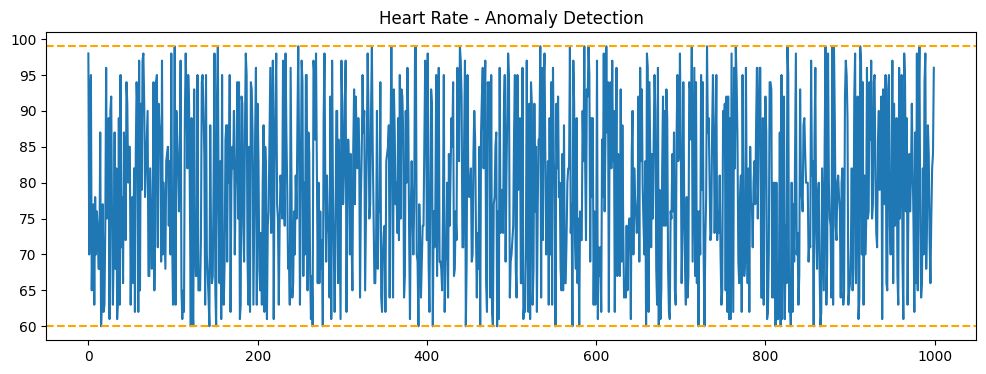


📊 Plotting: SpO2


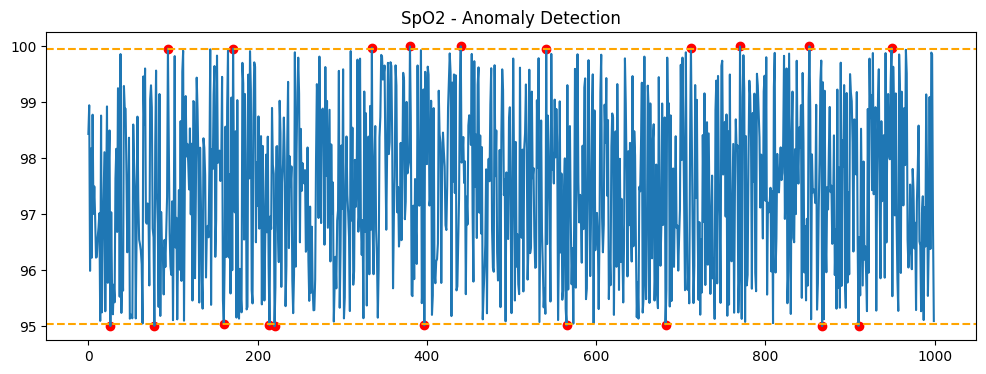


📊 Plotting: Respiration


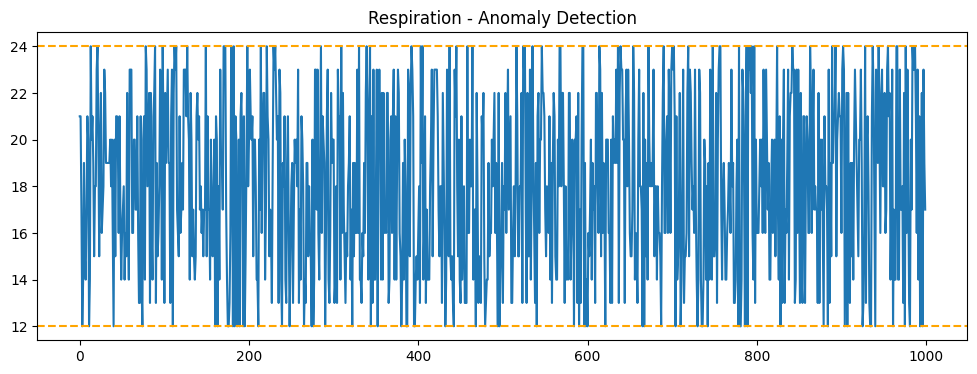


📊 Plotting: Systolic


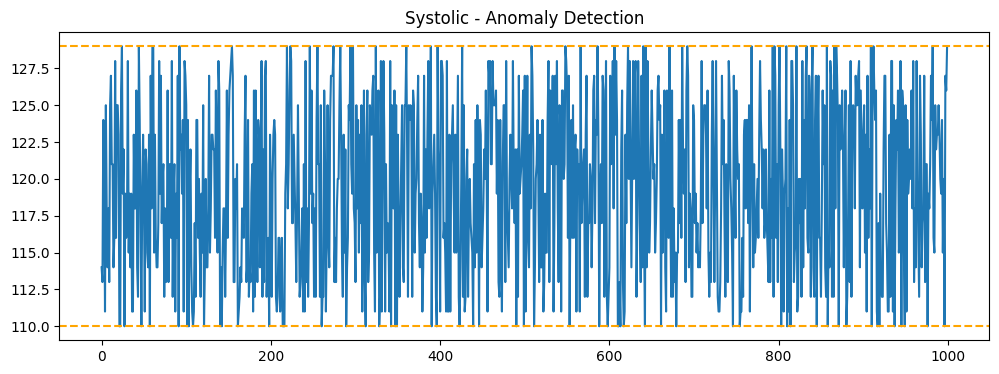


📊 Plotting: Diastolic


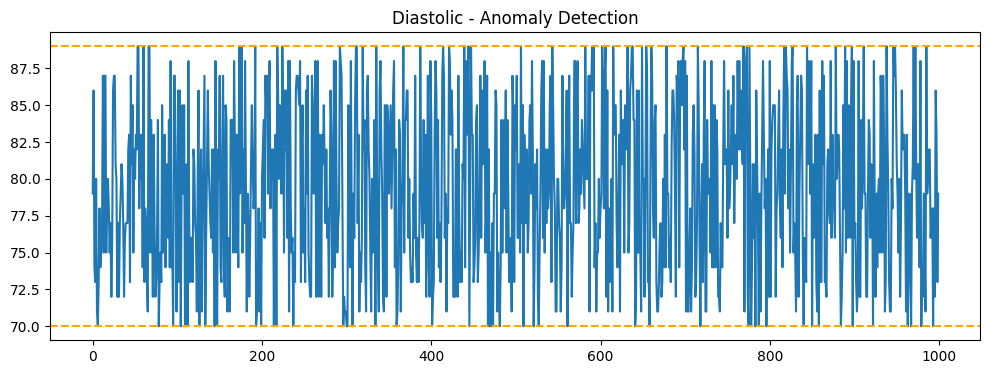

,Heart Rate,SpO2,Respiration,Systolic,Diastolic
0,98,98.433312,21,114.0,79.0
1,70,98.944505,21,113.0,86.0
2,91,95.990753,17,124.0,74.0
3,95,98.173643,12,120.0,73.0
4,65,96.225051,14,111.0,80.0
...,...,...,...,...,...
995,66,96.380705,22,120.0,72.0
996,75,99.885334,12,110.0,86.0
997,82,99.851796,23,127.0,83.0
998,84,96.829325,19,126.0,73.0


In [10]:
process_file("../data/raw/psychological_state_dataset.csv")


Columns found: ['heart_rate', 'max', 'start_time', 'end_time', 'create_time', 'update_time', 'min']
Detected: {'hr': 'heart_rate'}

Final Data Used:
   Heart Rate
0          74
1          62
2          68
3          75
4          69

Health Summary: Counter({'Normal': 5600, 'Risk': 177})

📊 Plotting: Heart Rate


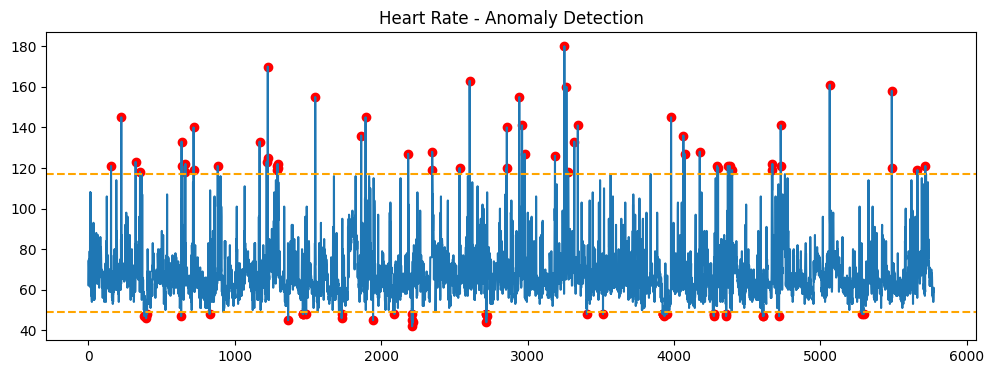

,Heart Rate
0,74
1,62
2,68
3,75
4,69
...,...
5772,54
5773,56
5774,61
5775,59


In [11]:
process_file("../data/com.samsung.health.csv")



⚠️ Fixing malformed CSV...
Columns found: ['Patient ID', 'Timestamp', 'Age', 'Gender', 'Weight', 'Height', 'BMI', 'Heart Rate', 'BP Systolic', 'BP Diastolic', 'SpO2', 'Respiration Rate', 'Body Temperature', 'Blood Glucose', 'Activity Level', 'Sleep Pattern']
Detected: {'hr': 'Heart Rate', 'spo2': 'SpO2', 'resp': 'Respiration Rate', 'bp_sys': 'BP Systolic', 'bp_dia': 'BP Diastolic'}

Final Data Used:
   Heart Rate       SpO2  Respiration    Systolic  Diastolic
0   69.480724  97.455695    13.401999  110.991309  72.106177
1   81.626960  98.091475    20.123960  123.481446  74.988467
2   78.208355  98.166750    16.402093  119.728994  84.853938
3   71.986469  99.397634    14.415860  144.005889  80.772643
4   77.933989        NaN    15.067093  123.242394  76.127575

Health Summary: Counter({'Normal': 1041770, 'Critical': 3818, 'Risk': 2987})

📊 Plotting: Heart Rate


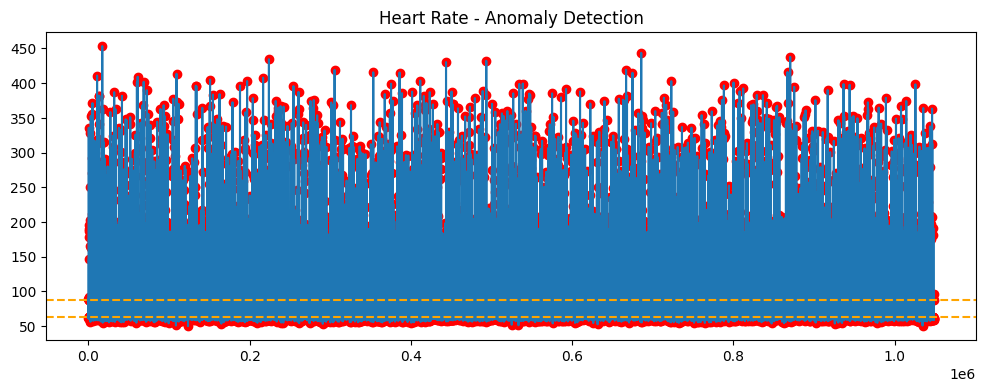


📊 Plotting: SpO2


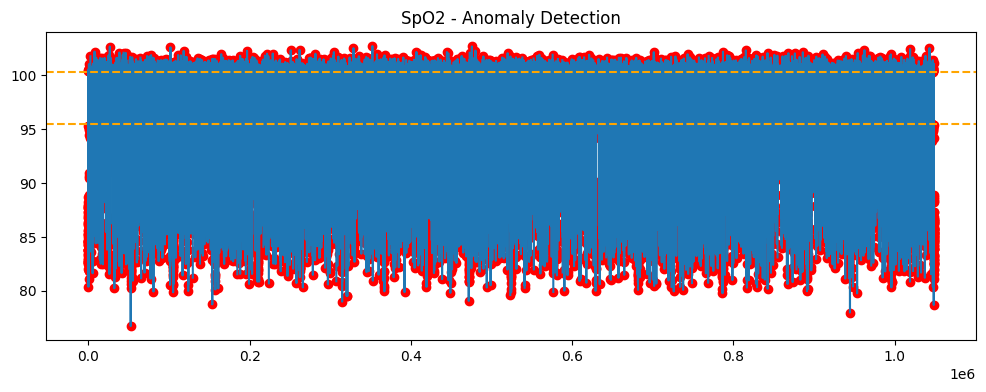


📊 Plotting: Respiration


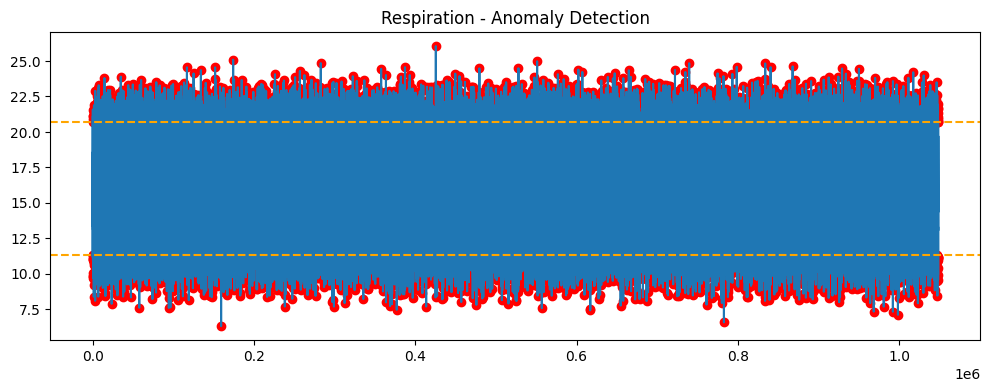


📊 Plotting: Systolic


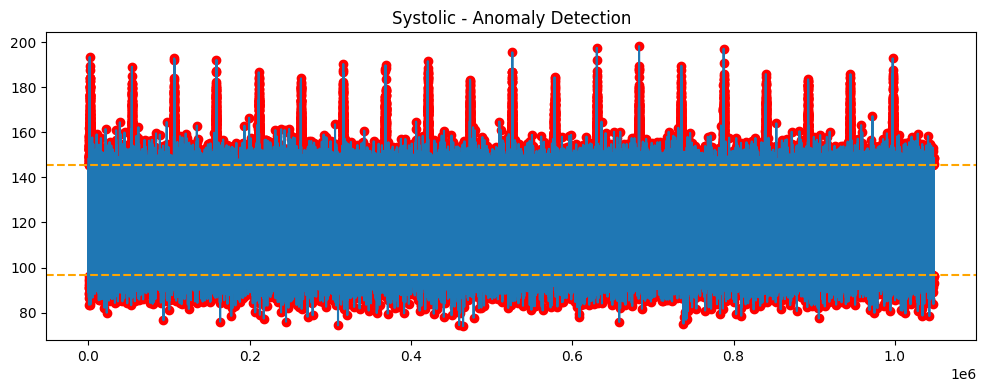


📊 Plotting: Diastolic


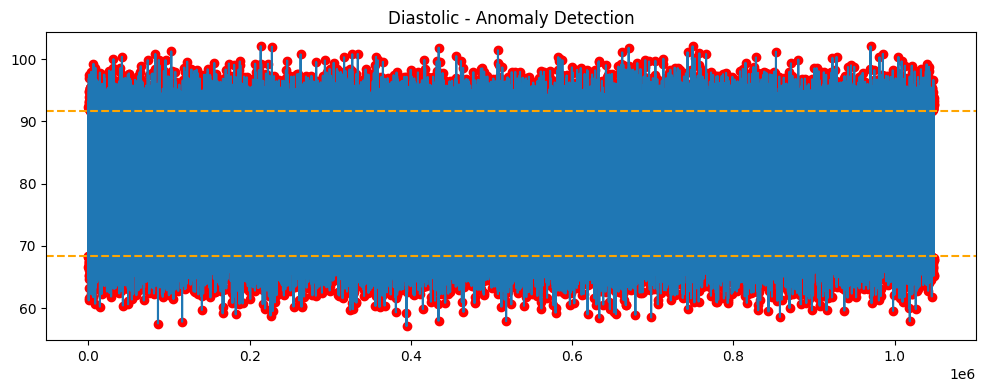

,Heart Rate,SpO2,Respiration,Systolic,Diastolic
0,69.480724,97.455695,13.401999,110.991309,72.106177
1,81.626960,98.091475,20.123960,123.481446,74.988467
2,78.208355,98.166750,16.402093,119.728994,84.853938
3,71.986469,99.397634,14.415860,144.005889,80.772643
4,77.933989,NaN,15.067093,123.242394,76.127575
...,...,...,...,...,...
1048570,73.511602,98.501705,15.200149,123.560441,84.474369
1048571,75.205599,100.164364,15.625411,125.381607,73.557171
1048572,84.364012,NaN,15.779347,115.520593,81.218639
1048573,76.849813,NaN,19.700058,129.796339,90.909814


In [39]:
process_file("../data/realistic_synthetic_health_dataset.csv")
